### Architecture
In this experiments, we applied auxiliary task learning where SWIN transformer extracts a shared 1536-dim(last layer) feature vector. This vector is fed simultaneously into a main head predicting Pawpularity and one or more auxiliary heads predicting BRISQUE quality score and pet visibility ratio. Head is MLP with two layers, and the total loss `L = L_paw + 0.1 × L_aux` is backpropagated through the shared backbone in a single pass, forcing it to learn representations useful for both the main task and the semantic auxiliary tasks. The auxiliary label is brisque which is a no-reference image quality metric that estimates perceptual image quality from local patch statistics. The lower values indicate sharper, less noisy images


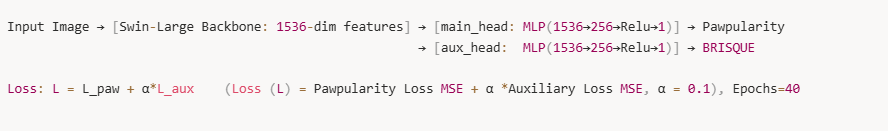

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
sys.path.insert(0, os.path.abspath("../.."))

In [3]:
# 1 imports and paths
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import gc

gc.enable()

import torch
from src.config import EXP_CONFIGS
from src.utils import set_seed, save_config

main_folder = "../.."
img_folder  = os.path.join(main_folder, "data", "train")
out_dir     = os.path.join(main_folder, "outputs", "extra", "exp15_swin_384_strong_MSE_aux_brisque_normalized_fixNormLeakage_brisque_strongHead_epochs_40")
out_csv     = os.path.join(main_folder, "data", "train_with_brisque_on_original_image.csv")

os.makedirs(out_dir, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
#  generate pseudo-labels if not already done, load CSV, set cfg

import sys
sys.path.insert(0, os.path.join(main_folder))
from src.gen_pseudo_labels import generate_pseudo_labels

# --- generate all pseudo-labels (skips if CSV already exists) ---
df_raw = pd.read_csv(os.path.join(main_folder, "data", "train.csv"))

df = generate_pseudo_labels(
    df=df_raw,
    img_folder=img_folder,
    out_csv=out_csv,
    run_brisque=True,
    run_yolo=False,
    force_recompute=False,
)


TARGET = "Pawpularity"

# --- set cfg ---
cfg = EXP_CONFIGS["exp15_aux_brisque"].copy()
cfg["img_size"] = 384
cfg["name"]     = "exp15_swin_384_aux_brisque_MSE_brisque_normalized_fixNormLeakage_brisque_strongHead_epochs_40"
cfg["loss"]     = "mse"
cfg["head_type"] = "mlp"#strong head , linear or mlp
cfg["epochs"]    = 40

save_config(cfg, out_dir)
set_seed(cfg["seed"])



Pseudo-label CSV already exists, loading: ../../data/train_with_brisque_on_original_image.csv


In [5]:
#

from src.plot import plot_pseudo_label_analysis

pseudo_cols = [c for c in ["BRISQUE"] if c in df.columns]

# simple stats
print("Pseudo-label statistics:")
print(df[pseudo_cols].describe().round(3))

print("\nCorrelation with Pawpularity:")
for col in pseudo_cols:
    r = df[col].corr(df["Pawpularity"])
    print(f"  {col}: r = {r:.4f}")



Pseudo-label statistics:
        BRISQUE
count  9912.000
mean     20.193
std      13.169
min     -17.807
25%      11.219
50%      17.635
75%      26.913
max     147.047

Correlation with Pawpularity:
  BRISQUE: r = 0.0371


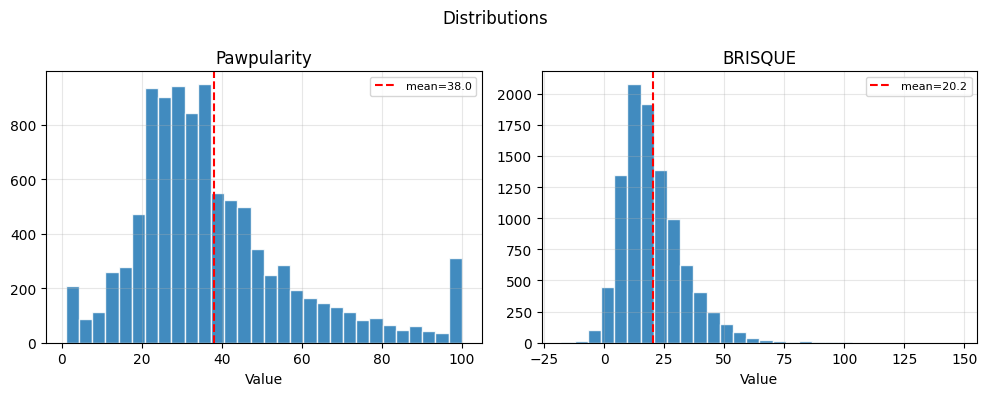

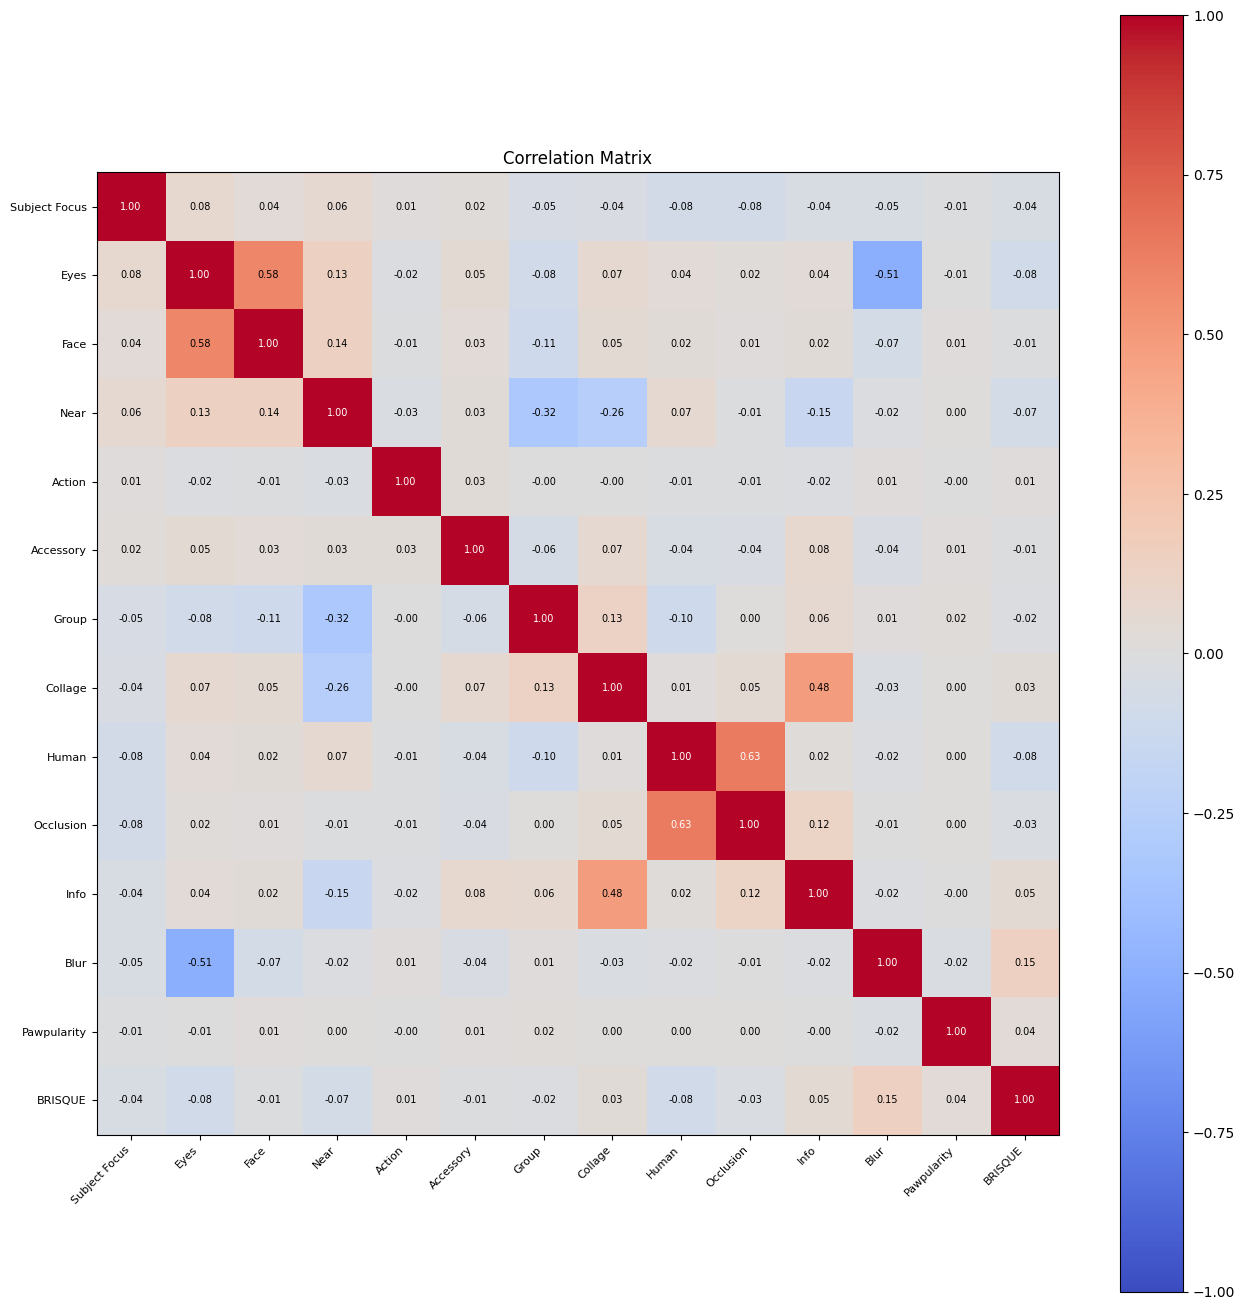

In [6]:
#cell 3b
# plots
plot_pseudo_label_analysis(
    df=df,
    pseudo_cols=pseudo_cols,
    target_col="Pawpularity",
    out_dir=out_dir,
)

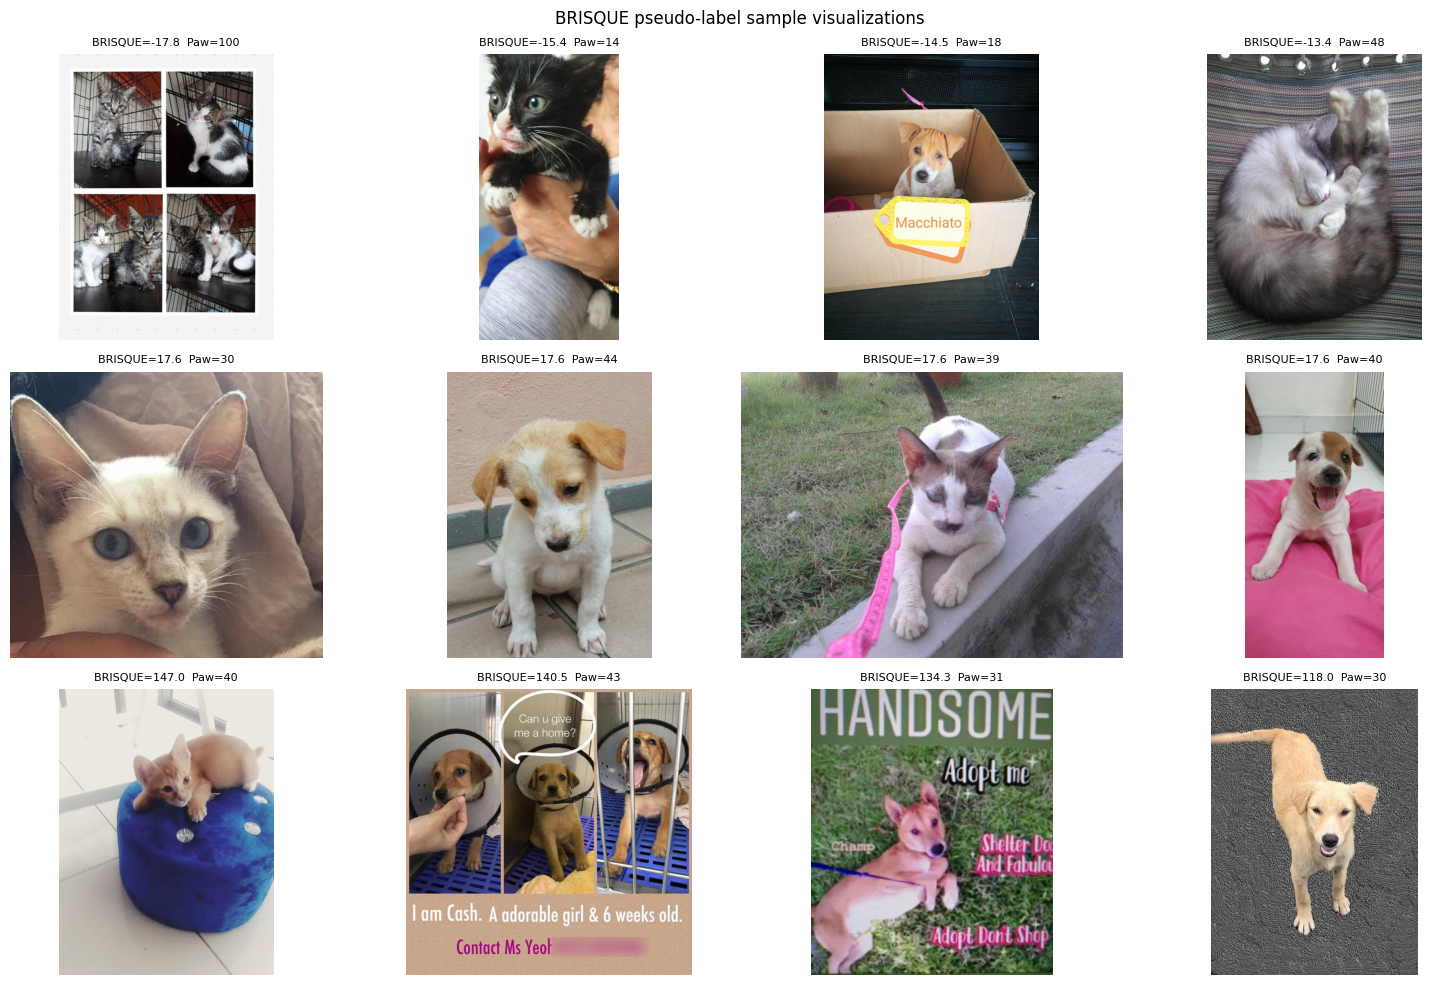

In [7]:
# sample images — low / mid / high BRISQUE
# shows the pseudo-label

df_vis = df[["Id", "Pawpularity", "BRISQUE"]].copy()

low  = df_vis.nsmallest(4, "BRISQUE")
mid  = df_vis.iloc[(df_vis["BRISQUE"] - df_vis["BRISQUE"].median()).abs().argsort()[:4]]
high = df_vis.nlargest(4, "BRISQUE")

groups = [
    ("Low BRISQUE\n(good quality)",  low),
    ("Mid BRISQUE",                  mid),
    ("High BRISQUE\n(poor quality)", high),
]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for row_idx, (group_label, group_df) in enumerate(groups):
    for col_idx, (_, r) in enumerate(group_df.iterrows()):
        ax = axes[row_idx][col_idx]
        img = Image.open(os.path.join(img_folder, r["Id"] + ".jpg")).convert("RGB")
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(f"BRISQUE={r['BRISQUE']:.1f}  Paw={r['Pawpularity']}", fontsize=8)
    axes[row_idx][0].set_ylabel(group_label, fontsize=9, rotation=0,
                                labelpad=130, va="center")

plt.suptitle("BRISQUE pseudo-label sample visualizations", fontsize=12)
plt.tight_layout()
plt.show()

In [8]:
# normalize BRISQUE  moved to fold loop to avoid data leakage
# brisque_min = df["BRISQUE"].min()
# brisque_max = df["BRISQUE"].max()
# df["BRISQUE"] = (df["BRISQUE"] - brisque_min) / (brisque_max - brisque_min) * 100

# print(f"BRISQUE normalized to [0,100] in memory (CSV unchanged)")
# print(df["BRISQUE"].describe())

In [9]:

from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from src.train import run_single_fold
import time

kf = KFold(n_splits=cfg["n_splits"], shuffle=True, random_state=cfg["seed"])
oof_pred = np.zeros(len(df))
oof_true = df[TARGET].values
fold_index = np.full(len(df), -1, dtype=int)
fold_rmse = []

start_all = time.time()
for fold, (tr_idx, val_idx) in enumerate(kf.split(df), start=1):
    print(f"\n=== {cfg['name']}: Fold {fold} ===")
    train_df = df.iloc[tr_idx].reset_index(drop=True)
    val_df   = df.iloc[val_idx].reset_index(drop=True)

    # BRISQUE per-fold min-max from TRAIN ONLY
    b_min = train_df["BRISQUE"].min()
    b_max = train_df["BRISQUE"].max()
    eps = 1e-9 # to avoid division by zero
    train_df["BRISQUE"] = (train_df["BRISQUE"] - b_min) / (b_max - b_min + eps) * 100.0
    val_df["BRISQUE"]   = (val_df["BRISQUE"]   - b_min) / (b_max - b_min + eps) * 100.0

    best_rmse, val_preds, val_targets, val_ids = run_single_fold(
        fold=fold,
        train_df=train_df,
        val_df=val_df,
        img_folder=img_folder,
        cfg=cfg,
        out_dir=out_dir,
        device=device,
        mode="image",
        tab_cols=None,
        workers=16,
        pin_memory=True,
        persistent_workers=True,
    )

    oof_pred[val_idx] = val_preds
    fold_index[val_idx] = fold
    fold_rmse.append(best_rmse)
    print(f"Fold {fold} best RMSE: {best_rmse:.4f}")


all_sec = time.time() - start_all
print(f"\nTotal training time: {int(all_sec//60)}m {int(all_sec%60)}s")
# final metrics + OOF with fold column
oof_rmse = root_mean_squared_error(oof_true, oof_pred)
fold_rmse = np.array(fold_rmse)
print(f"\nOOF RMSE: {oof_rmse:.4f}")
print(f"Fold RMSEs: {fold_rmse.tolist()}  Mean={fold_rmse.mean():.4f}  Std={fold_rmse.std():.4f}")

oof_df = pd.DataFrame({
    "Id": df["Id"],
    "fold": fold_index,      
    "ytrue": oof_true,
    "oof_pred": oof_pred,
})
oof_df["abs_err"] = (oof_df["ytrue"] - oof_df["oof_pred"]).abs()
oof_df.to_csv(os.path.join(out_dir, "oof_detail.csv"), index=False)
oof_df.sort_values("abs_err", ascending=False).head(50).to_csv(
    os.path.join(out_dir, "top50_errors.csv"), index=False
)

np.save(os.path.join(out_dir, "oof_pred.npy"), oof_pred)
np.save(os.path.join(out_dir, "fold_rmse.npy"), fold_rmse)
with open(os.path.join(out_dir, "metrics.txt"), "w") as f:
    f.write(f"OOF_RMSE: {oof_rmse:.4f}\n")
    f.write(f"Fold_RMSE: {fold_rmse.tolist()}\nMean: {fold_rmse.mean():.4f}\nStd: {fold_rmse.std():.4f}\n")


/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



=== exp15_swin_384_aux_brisque_MSE_brisque_normalized_fixNormLeakage_brisque_strongHead_epochs_40: Fold 1 ===
Epoch 1/40 | Fold 1 | Train[MSE]: PawRMSE=23.7469 TotalLoss=577.0912 | ValRMSE: 21.0309 | brisque_val_mse: 75.6884
Epoch 2/40 | Fold 1 | Train[MSE]: PawRMSE=20.5274 TotalLoss=428.1773 | ValRMSE: 21.0413 | brisque_val_mse: 75.5471
Epoch 3/40 | Fold 1 | Train[MSE]: PawRMSE=20.2035 TotalLoss=415.0343 | ValRMSE: 19.4597 | brisque_val_mse: 76.1336
Epoch 4/40 | Fold 1 | Train[MSE]: PawRMSE=18.7686 TotalLoss=359.1063 | ValRMSE: 18.3138 | brisque_val_mse: 75.2475
Epoch 5/40 | Fold 1 | Train[MSE]: PawRMSE=17.6536 TotalLoss=318.4532 | ValRMSE: 18.6606 | brisque_val_mse: 75.4607
Epoch 6/40 | Fold 1 | Train[MSE]: PawRMSE=16.8334 TotalLoss=290.1078 | ValRMSE: 18.2880 | brisque_val_mse: 74.6522
Epoch 7/40 | Fold 1 | Train[MSE]: PawRMSE=16.0718 TotalLoss=265.0065 | ValRMSE: 17.8066 | brisque_val_mse: 74.5285
Epoch 8/40 | Fold 1 | Train[MSE]: PawRMSE=15.1181 TotalLoss=235.2006 | ValRMSE: 17.7

In [4]:

import pandas as pd
df = pd.read_csv(out_dir+"/oof_detail.csv")
fold_rmse = []

for fold in range(1, 6):
    sub = df[df.fold == fold]
    rmse = ((sub.ytrue - sub.oof_pred)**2).mean() ** 0.5
    fold_rmse.append(rmse)
    print(f"Fold {fold} OOF RMSE: {rmse:.4f} (n={len(sub)})")

Fold 1 OOF RMSE: 17.7055 (n=1983)
Fold 2 OOF RMSE: 18.2274 (n=1983)
Fold 3 OOF RMSE: 18.0820 (n=1982)
Fold 4 OOF RMSE: 17.8129 (n=1982)
Fold 5 OOF RMSE: 17.9918 (n=1982)


In [5]:
# aux-task validation metrics 



baseline_rmse_path = os.path.join(
    "../..", "outputs", "extra", "exp3_swin_384_strong_MSE_MLPHead", "fold_rmse.npy"
)
aux_rmse_path = os.path.join(out_dir, "fold_rmse.npy")

if os.path.exists(baseline_rmse_path) and os.path.exists(aux_rmse_path):
    fold_rmse_base = np.load(baseline_rmse_path)
    fold_rmse_aux  = np.load(aux_rmse_path)

    print(f"\n{'Model':<35} {'Mean':>7} {'Std':>6}  Fold RMSEs")
    print(f"{'Swin image-only (exp3)':<35} "
          f"{fold_rmse_base.mean():>7.4f} {fold_rmse_base.std():>6.4f}  "
          f"{[round(x,4) for x in fold_rmse_base.tolist()]}")
    print(f"{'Swin + BRISQUE aux (exp15)':<35} "
          f"{fold_rmse_aux.mean():>7.4f} {fold_rmse_aux.std():>6.4f}  "
          f"{[round(x,4) for x in fold_rmse_aux.tolist()]}")

    


Model                                  Mean    Std  Fold RMSEs
Swin image-only (exp3)              17.7337 0.2876  [17.7702, 18.0767, 17.3341, 17.4841, 18.0031]
Swin + BRISQUE aux (exp15)          17.9639 0.1864  [17.7055, 18.2274, 18.082, 17.8129, 17.9918]


In [6]:
#  per-epoch BRISQUE val MSE curve
# Aux loss

all_logs = []
for fold in range(1, 6):
    lp = os.path.join(out_dir, f"epoch_logs_fold{fold}.csv")
    if os.path.exists(lp):
        all_logs.append(pd.read_csv(lp))

if all_logs:
    logs_df = pd.concat(all_logs).reset_index(drop=True)

    if "val_brisque_mse" in logs_df.columns:
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))

        for fold_i in range(1, 6):
            fold_log = logs_df[logs_df["fold"] == fold_i]
            if fold_log.empty:
                continue
            axes[0].plot(fold_log["epoch"], fold_log["val_rmse"],
                         label=f"fold {fold_i}", alpha=0.85)
            axes[1].plot(fold_log["epoch"], fold_log["val_brisque_mse"],
                         label=f"fold {fold_i}", alpha=0.85)

        axes[0].set_title("Main task — val RMSE (Pawpularity) per epoch")
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("RMSE")
        axes[0].legend(fontsize=8)
        axes[0].grid(alpha=0.3)

        axes[1].set_title("Aux head — val MSE (BRISQUE) per epoch\n"
                          )
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("MSE")
        axes[1].legend(fontsize=8)
        axes[1].grid(alpha=0.3)

        plt.suptitle("Aux-task learning curves", fontsize=11)
        plt.tight_layout()
        
        plt.show()

       

In [7]:
logs_df.head()

,fold,epoch,train_loss,train_paw_loss,val_rmse,loss_brisque,brisque_val_mse
0,1,1,577.091224,563.917173,21.030878,131.740517,75.688446
1,1,2,428.177261,421.374455,21.041348,68.028057,75.547104
2,1,3,415.034287,408.180241,19.459702,68.540464,76.133606
3,1,4,359.106268,352.261810,18.313795,68.444587,75.247543
4,1,5,318.453152,311.648085,18.660566,68.050679,75.460716


### Training and Validation Loss Curve

In [8]:
from src.plot import plot_train_val_history
out_dir1 = os.path.join("../..", "outputs","extra", "exp3_swin_384_strong_MSE_MLPHead")


### Side by Side Comparison with Image only

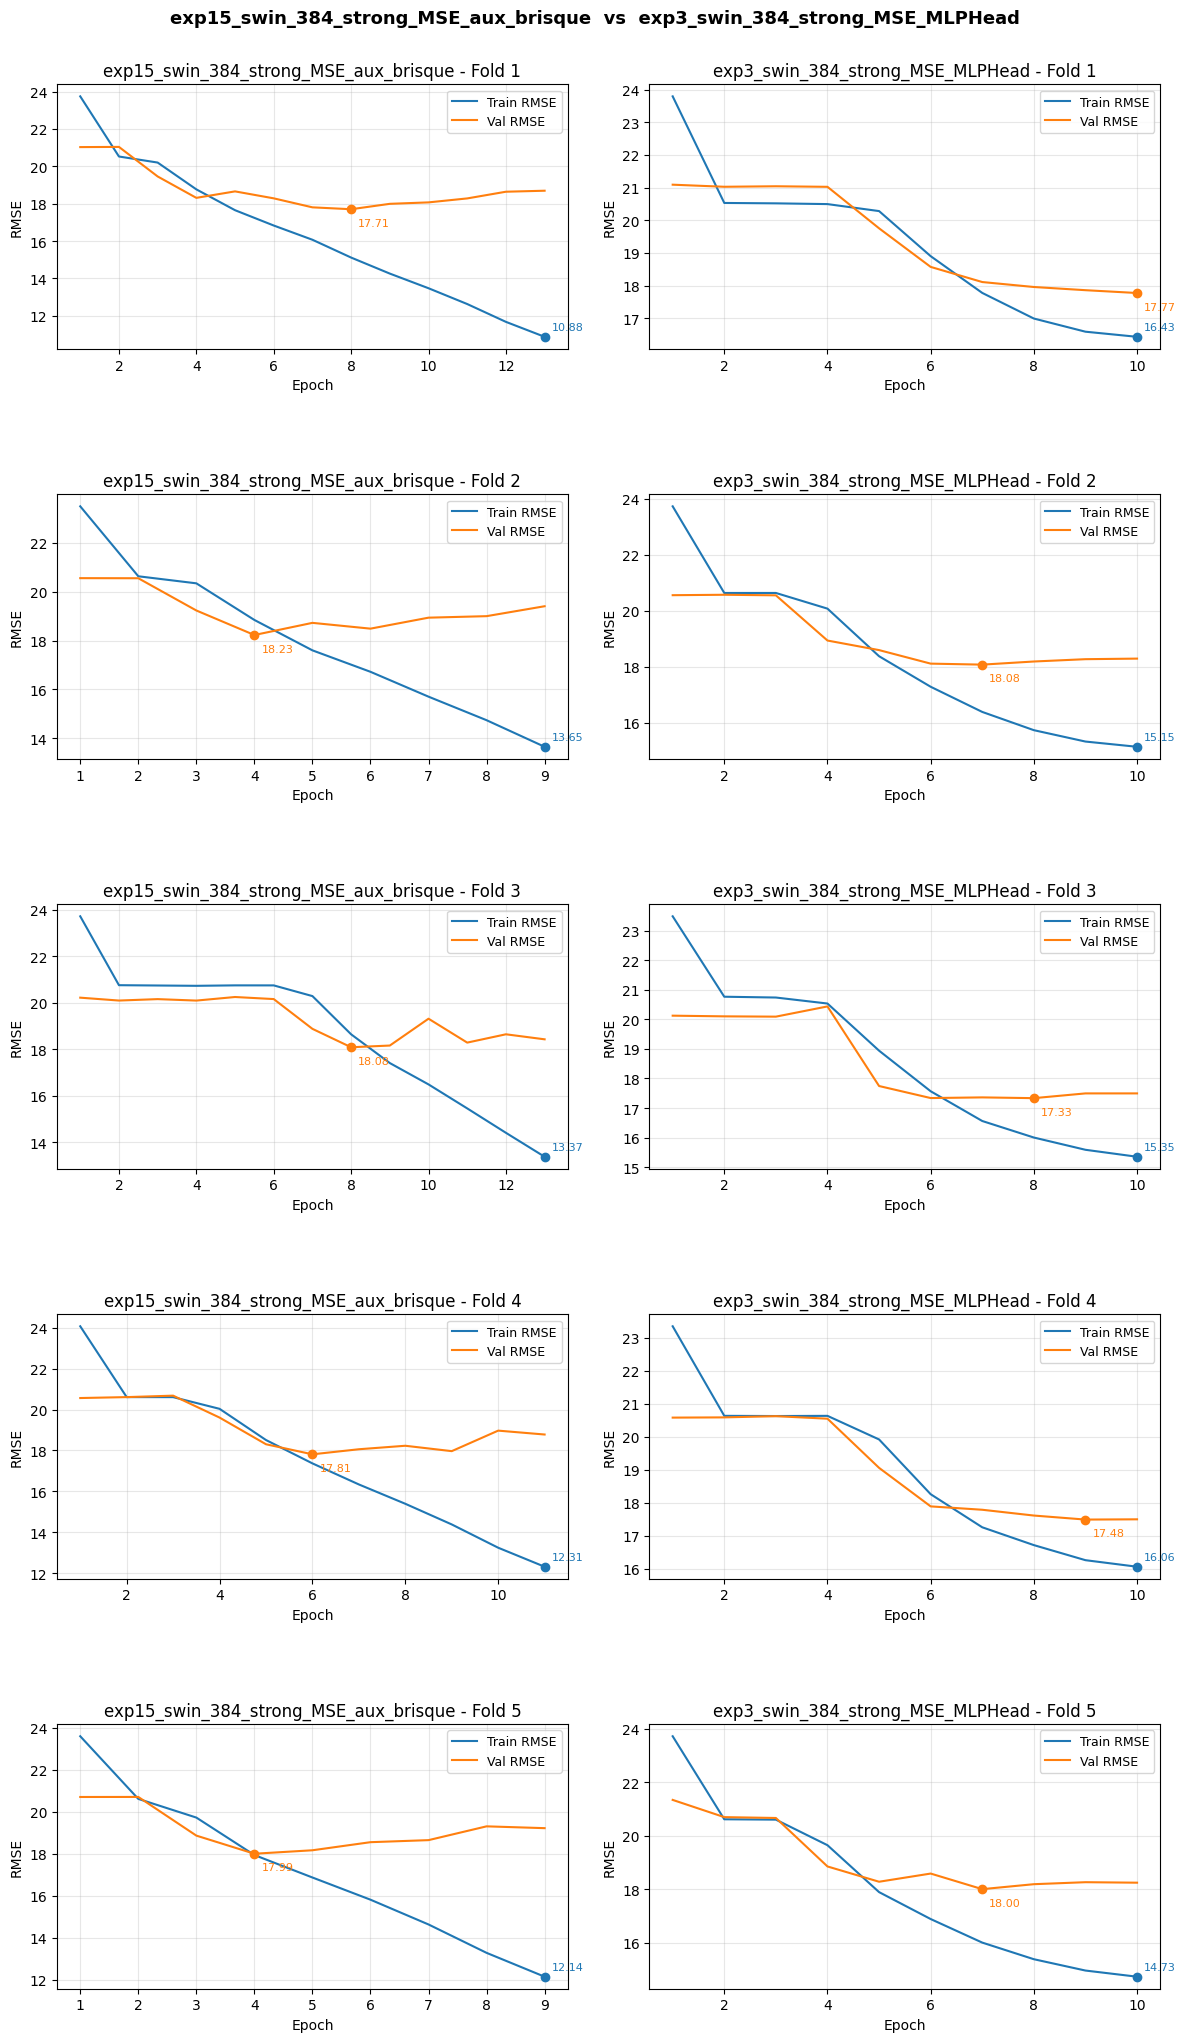

In [9]:
### Side by Side Comparison with Concatenation based Feature Fusion Exp4
from src.plot import plot_compare_two_experiments
plot_compare_two_experiments(out_dir, out_dir1,folds=[1,2,3,4,5], label_a="exp15_swin_384_strong_MSE_aux_brisque", label_b="exp3_swin_384_strong_MSE_MLPHead")


In [10]:
#  Inspect worst error rows

errors_path = os.path.join(out_dir, "top50_errors.csv")
err_df = pd.read_csv(errors_path)
err_df.head()

,Id,fold,ytrue,oof_pred,abs_err
0,4435d6f98ad72782ca0cf61f946b016d,5,100,28.254671,71.745329
1,d00e5d29d4ec09de1e0e0ebec41b2d03,1,5,75.669983,70.669983
2,2c4e3ff2fce74d3db4dfb2cc625dd91e,1,100,29.576498,70.423502
3,e638853bdec13e6cc76b69f169b34740,4,96,25.718172,70.281828
4,1e59bc4bf0f630df8f17fb908b7c13c2,1,100,30.110941,69.889059


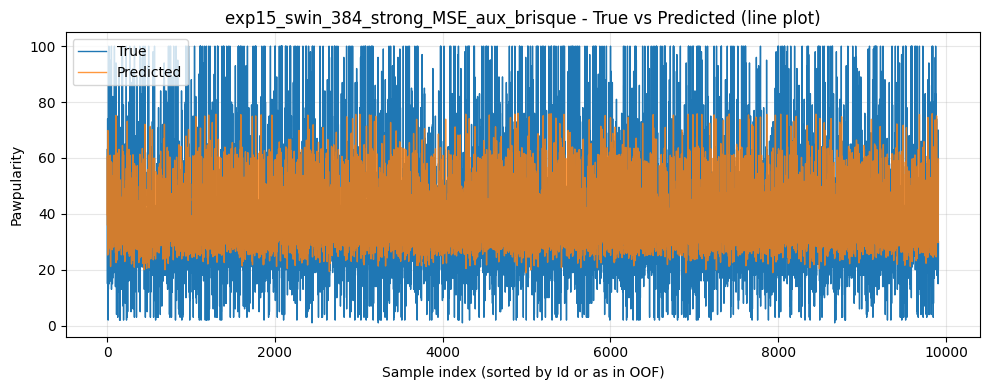

In [11]:
import os
import pandas as pd
from src.plot import (
   plot_oof_true_pred_lines,
    show_images_grid,
)

# Load OOF detail and top-errors
oof_df = pd.read_csv(os.path.join(out_dir, "oof_detail.csv"))
err_df = pd.read_csv(os.path.join(out_dir, "top50_errors.csv"))

# Plot
plot_oof_true_pred_lines(oof_df, title_prefix="exp15_swin_384_strong_MSE_aux_brisque")





exp15_swin_384_strong_MSE_aux_brisque OOF RMSE: 17.964905278850967
exp3_swin_384_strong_MSE_MLPHead OOF RMSE: 17.73602090865089
ΔRMSE (exp3_swin_384_strong_MSE_MLPHead - exp15_swin_384_strong_MSE_aux_brisque): -0.22888437020007757


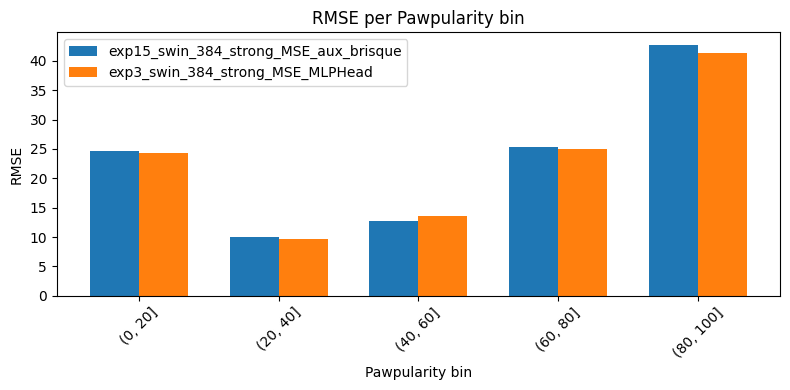

In [12]:
from src.plot import compare_oof_by_bins
bins = [0, 20, 40, 60, 80, 100]

df_bins, rmse3_all, rmse5_all, gap = compare_oof_by_bins(
    oof_path_a=os.path.join(out_dir, "oof_detail.csv"),
    oof_path_b=os.path.join(out_dir1, "oof_detail.csv"),
    bins=bins,
    label_a="exp15_swin_384_strong_MSE_aux_brisque",
    label_b="exp3_swin_384_strong_MSE_MLPHead",
    title_prefix="",
)

In [13]:
df_bins.head()

,bin,count,exp15_swin_384_strong_MSE_aux_brisque_rmse,exp3_swin_384_strong_MSE_MLPHead_rmse,rmse_diff,winner
0,"(0, 20]",1417,24.575980,24.383091,-0.192890,exp3_swin_384_strong_MSE_MLPHead_better
1,"(20, 40]",5119,9.981864,9.719382,-0.262482,exp3_swin_384_strong_MSE_MLPHead_better
2,"(40, 60]",2088,12.798069,13.504186,0.706117,exp15_swin_384_strong_MSE_aux_brisque_better
3,"(60, 80]",727,25.366529,25.028708,-0.337821,exp3_swin_384_strong_MSE_MLPHead_better
4,"(80, 100]",561,42.709140,41.275555,-1.433585,exp3_swin_384_strong_MSE_MLPHead_better


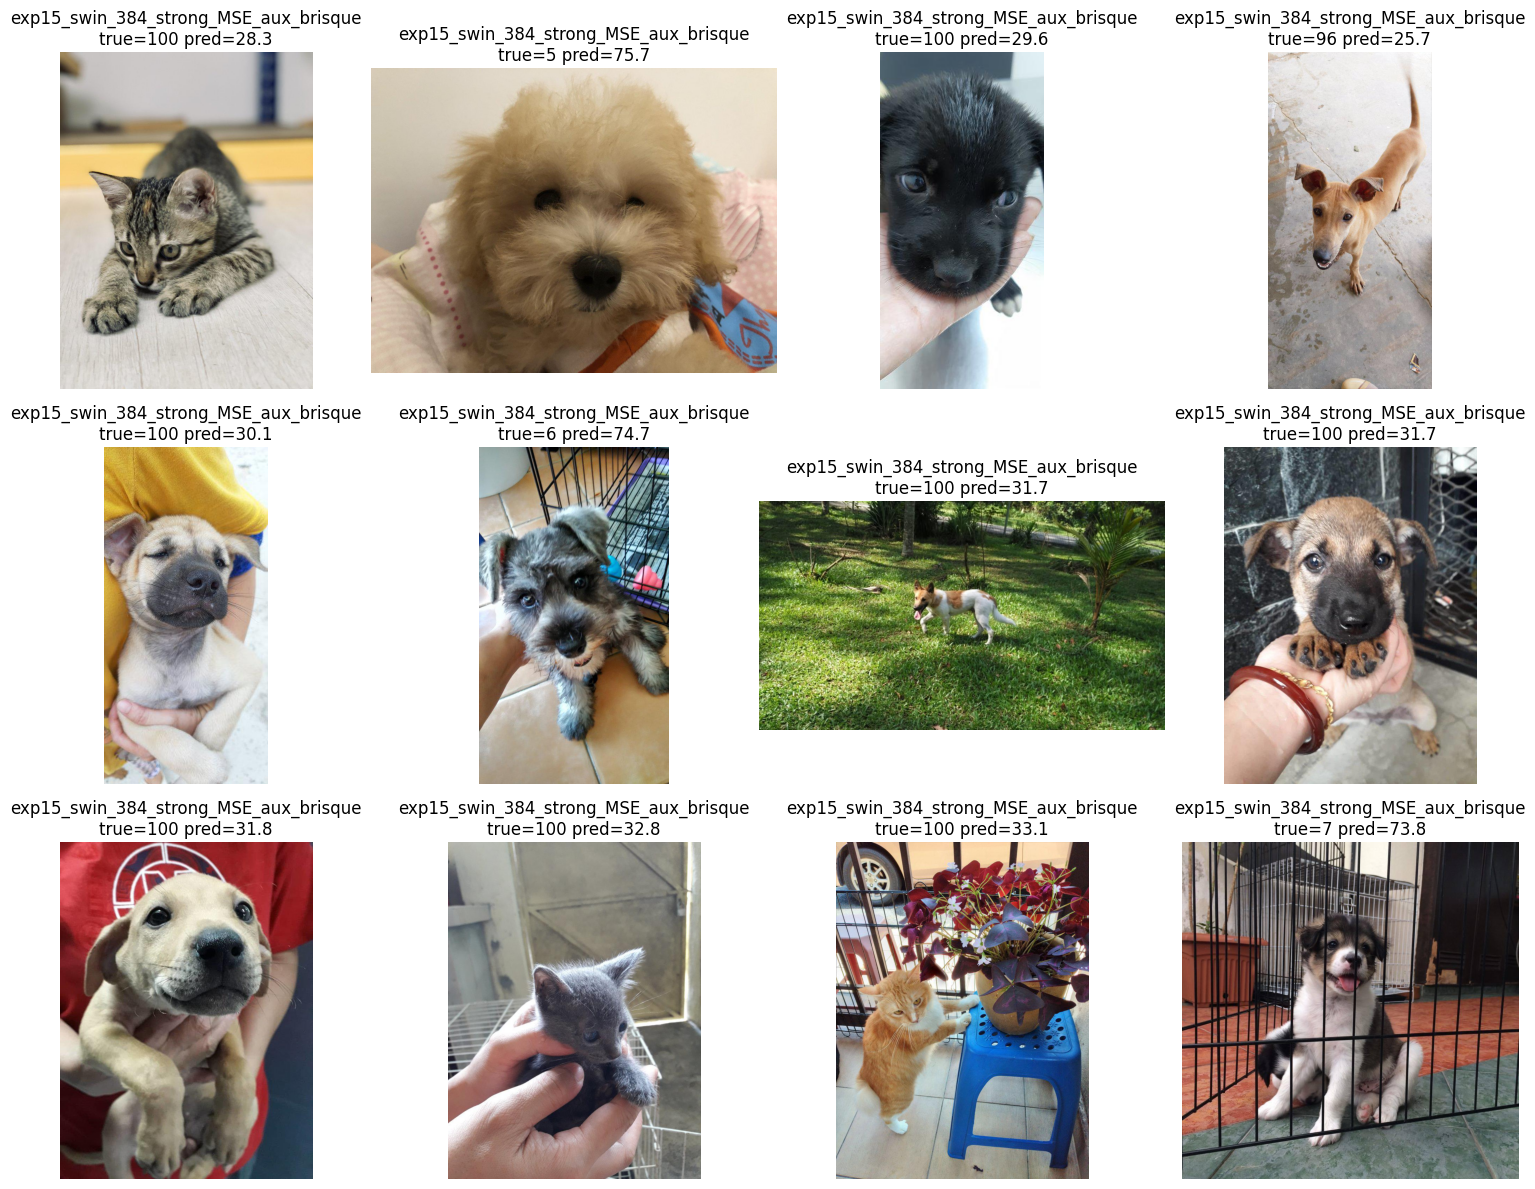

In [14]:
# Images of worst errors
img_folder = os.path.join(main_folder, "data", "train")
show_images_grid(err_df, img_folder, n=12, title_prefix="exp15_swin_384_strong_MSE_aux_brisque")

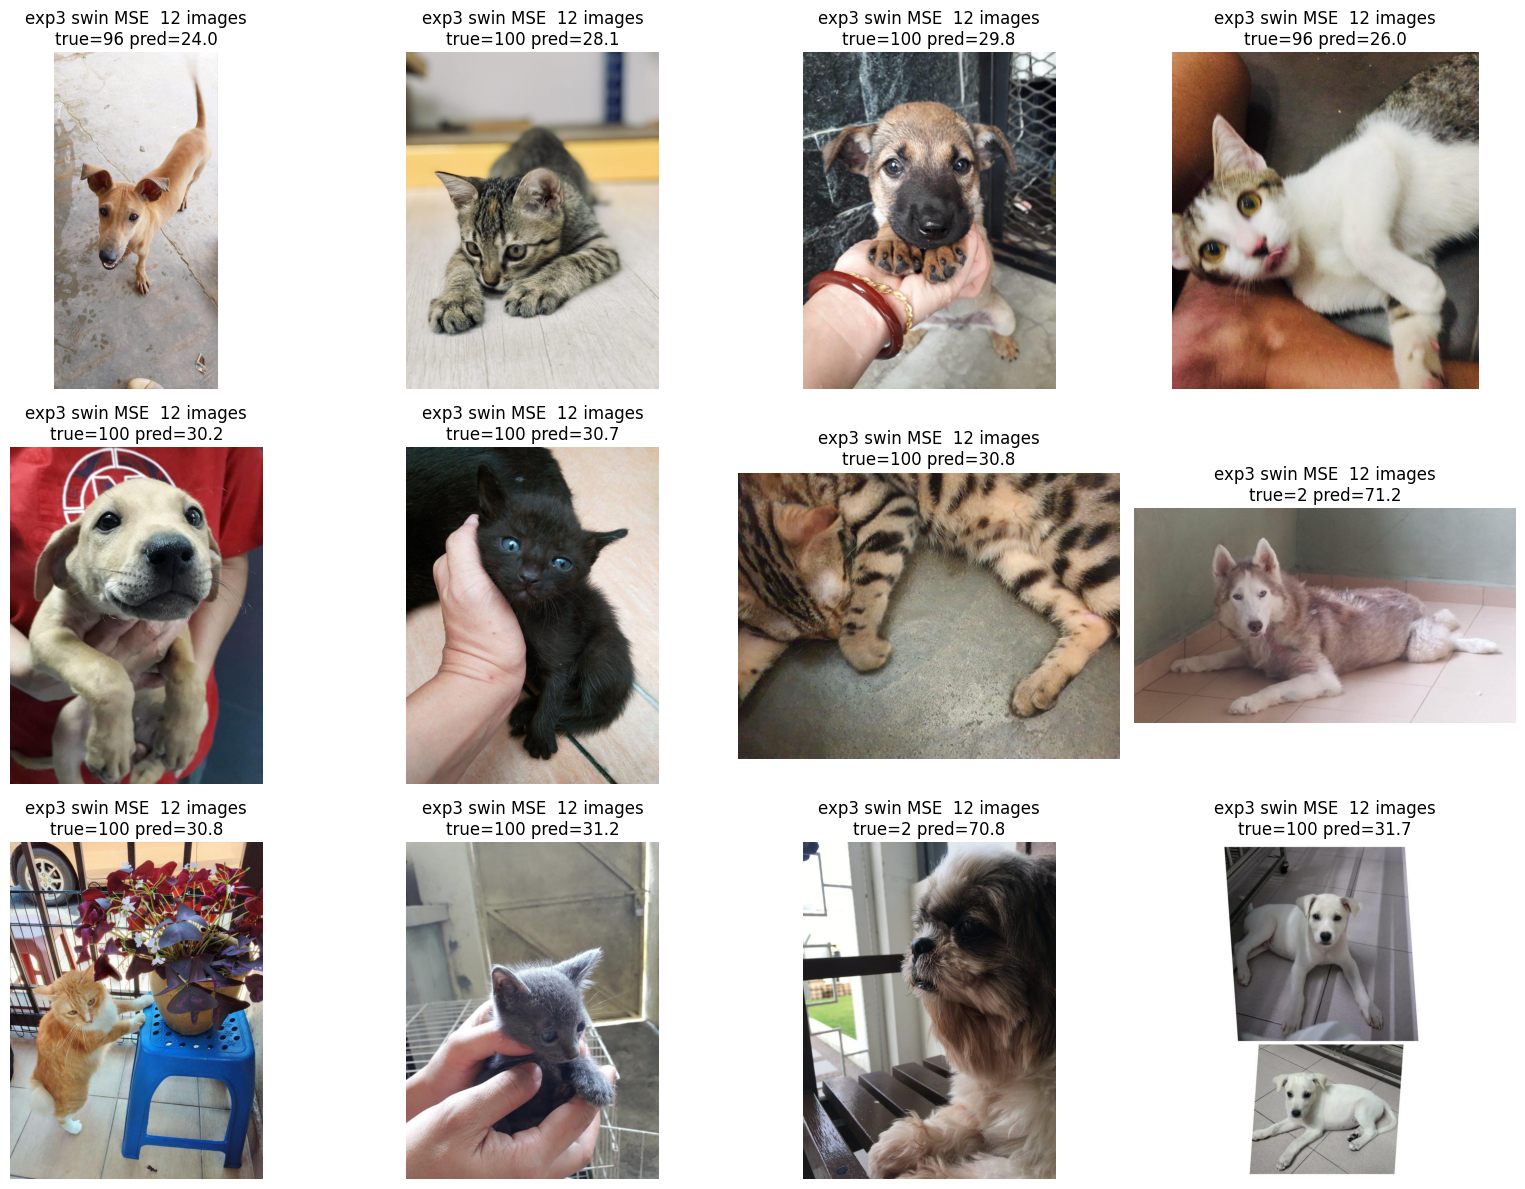

In [15]:
# Load OOF detail and top-errors of Exp4 
oof_df1 = pd.read_csv(os.path.join(out_dir1, "oof_detail.csv"))
err_df1 = pd.read_csv(os.path.join(out_dir1, "top50_errors.csv"))
show_images_grid(err_df1, img_folder, n=12, title_prefix="exp3 swin MSE  12 images")